# Feature Selection Pipeline (Single Methods & Voting Mechnisms)

This notebook implements a unified pipeline to test 5 distinct Feature Ranking methods (including SHAP) and 3 Voting Ensembles across Logistic Regression, SVM, and XGBoost (baseline models - no tuning). 

**Steps:**
1. Filter Multicollinearity.
2. Calculate Fold-specific feature importance (preventing data leakage).
3. Evaluate $K=1$ to $30$ for all models and methods.
4. Identify the absolute best single and voting method per model.
5. Extract final features on the full dataset and save to `.json`.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import time
import warnings
from collections import defaultdict

import shap
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoLarsIC, LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def load_and_filter_data(x_path, y_path, threshold=0.85):
    """Loads data and filters highly correlated features."""
    X = pd.read_csv(x_path, sep=r'\s+')
    y = pd.read_csv(y_path, sep=r'\s+').iloc[:, 0] if isinstance(pd.read_csv(y_path, sep=r'\s+'), pd.DataFrame) else pd.read_csv(y_path, sep=r'\s+')
    
    print(f"Original X shape: {X.shape}")
    corr_matrix = X.corr(method='spearman').abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    X_filtered = X.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} collinear features. Remaining: {X_filtered.shape[1]}")
    return X_filtered, y, to_drop

data_x, data_y, dropped_cols = load_and_filter_data('../../data/x_train.txt', '../../data/y_train.txt')
top_k_target = 30

Original X shape: (5000, 500)
Dropped 10 collinear features. Remaining: 490


## 1. Feature Importance Ranking Algorithms (The Base Extractors)
Includes Spearman Corrrelation, Random Forest, Mutual Information, Lasso BIC, and SHAP (computed via XGBoost TreeExplainer).

In [8]:
def get_spearman_imp(X, y, top_k=30):
    corr = X.corrwith(y, method='spearman').abs().sort_values(ascending=False)
    return corr.head(top_k).index.tolist()

def get_rf_imp(X, y, top_k=30):
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X, y)
    imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    return imp.head(top_k).index.tolist()

def get_mi_imp(X, y, top_k=30):
    mi = mutual_info_regression(X, y, random_state=42)
    imp = pd.Series(mi, index=X.columns).sort_values(ascending=False)
    return imp.head(top_k).index.tolist()

def get_lasso_bic_imp(X_scaled, y, top_k=30):
    lasso = LassoLarsIC(criterion='bic').fit(X_scaled, y)
    imp = pd.Series(np.abs(lasso.coef_), index=X_scaled.columns).sort_values(ascending=False)
    return imp[imp > 0].head(top_k).index.tolist()

def get_shap_imp(X, y, top_k=30):
    """Uses XGBoost and TreeExplainer to calculate exact SHAP values."""
    xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss').fit(X, y)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X)
    
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    imp = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)
    return imp.head(top_k).index.tolist()

def generate_base_rankings(X, y, X_scaled, top_k=30):
    """Executes all base methods and returns a dictionary of lists."""
    return {
        'Spearman': get_spearman_imp(X, y, top_k),
        'RF': get_rf_imp(X, y, top_k),
        'MI': get_mi_imp(X, y, top_k),
        'Lasso_BIC': get_lasso_bic_imp(X_scaled, y, top_k),
        'SHAP': get_shap_imp(X, y, top_k)
    }

## 2. Ensemble Voting Algorithms for Rankings
Combines the base rankings using Standard (Hard), Tiered (Bracket), and Tree-Heavy Weighted voting logic.

In [9]:
def get_standard_voting(base_rankings, top_k=30):
    votes = defaultdict(int)
    for feats in base_rankings.values():
        for f in feats: votes[f] += 1
    return pd.Series(votes).sort_values(ascending=False).head(top_k).index.tolist()

def get_tiered_voting(base_rankings, top_k=30):
    points = defaultdict(int)
    for feats in base_rankings.values():
        for rank, f in enumerate(feats):
            if rank < 5: p = 6
            elif rank < 10: p = 5
            elif rank < 15: p = 4
            elif rank < 20: p = 3
            elif rank < 25: p = 2
            else: p = 1
            points[f] += p
    return pd.Series(points).sort_values(ascending=False).head(top_k).index.tolist()

def get_weighted_voting(base_rankings, weights, top_k=30):
    points = defaultdict(float)
    for method, feats in base_rankings.items():
        w = weights.get(method, 1.0)
        for rank, f in enumerate(feats):
            points[f] += (top_k - rank) * w
    return pd.Series(points).sort_values(ascending=False).head(top_k).index.tolist()

def generate_voting_rankings(base_rankings, top_k=30):
    """Executes voting ensembles based on the fold's base rankings."""
    tree_heavy_weights = {'Spearman': 1, 'RF': 2, 'MI': 1, 'Lasso_BIC': 1, 'SHAP': 2.5}
    return {
        'Standard_Voting': get_standard_voting(base_rankings, top_k),
        'Tiered_Voting': get_tiered_voting(base_rankings, top_k),
        'Tree_Heavy_Voting': get_weighted_voting(base_rankings, tree_heavy_weights, top_k)
    }

## 3. The Ranking Basic Evaluation Pipeline
By manually iterating the Cross-Validation folds, we scale the data only once per fold and extract predictions iteratively.

In [ ]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42, max_iter=2000, cache_size=1000),
    'XGBoost': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
}

all_method_names = ['Spearman', 'RF', 'MI', 'Lasso_BIC', 'SHAP', 'Standard_Voting', 'Tiered_Voting', 'Tree_Heavy_Voting']
k_values = list(range(1, top_k_target + 1))

# Initialize a structure to store OOF probabilities
# Format: oof_preds[model][method][k] = np.zeros(len(data_y))
oof_preds = {m: {meth: {k: np.zeros(len(data_y)) for k in k_values} for meth in all_method_names} for m in models}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting CV Pipeline...")
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(data_x, data_y)):
    fold_start = time.time()
    print(f"\n--- Processing Fold {fold + 1}/5 ---")
    
    X_tr, X_val = data_x.iloc[train_idx], data_x.iloc[val_idx]
    y_tr, y_val = data_y.iloc[train_idx], data_y.iloc[val_idx]
    
    scaler = StandardScaler()
    X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_val_sc = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
    
    fold_base_ranks = generate_base_rankings(X_tr, y_tr, X_tr_sc, top_k=top_k_target)
    fold_vote_ranks = generate_voting_rankings(fold_base_ranks, top_k=top_k_target)
    
    fold_all_ranks = {**fold_base_ranks, **fold_vote_ranks}
    
    for model_name, clf in models.items():
        X_t_use = X_tr if model_name == 'XGBoost' else X_tr_sc
        X_v_use = X_val if model_name == 'XGBoost' else X_val_sc
        
        for method_name, features in fold_all_ranks.items():
            for k in k_values:
                subset = features[:k]
                
                try:
                    clf.fit(X_t_use[subset], y_tr)
                    probs = clf.predict_proba(X_v_use[subset])[:, 1]
                    oof_preds[model_name][method_name][k][val_idx] = probs
                except Exception as e:
                    # SVM might hit max_iter and fail, assign 0 probability as penalty
                    oof_preds[model_name][method_name][k][val_idx] = 0.0
                    
    print(f"Fold {fold + 1} completed in {(time.time() - fold_start)/60:.1f} mins")

print(f"\nTotal CV Execution Time: {(time.time() - start_time)/60:.1f} minutes")

Starting CV Pipeline...

--- Processing Fold 1/5 ---
Fold 1 completed in 17.1 mins

--- Processing Fold 2/5 ---
Fold 2 completed in 13.3 mins

--- Processing Fold 3/5 ---
Fold 3 completed in 12.7 mins

--- Processing Fold 4/5 ---
Fold 4 completed in 12.4 mins

--- Processing Fold 5/5 ---
Fold 5 completed in 13.4 mins

Total CV Execution Time: 69.0 minutes
      


## 4. Scoring & Identifying the Winners
We apply the strict business logic: $(TP \times 10) - (FP \times 5) - (K \times 200)$ using the OOF probabilities generated above. We then extract the best Single method and the best Voting method for each base classifier (for reference, no tuning).

In [ ]:
def calculate_profit(y_true, y_probs, k, max_contacts=1000):
    sorted_idx = np.argsort(y_probs)[::-1]
    y_true_sorted = y_true.values[sorted_idx] if isinstance(y_true, pd.Series) else y_true[sorted_idx]
    
    tps = np.cumsum(y_true_sorted == 1)[:max_contacts]
    fps = np.cumsum(y_true_sorted == 0)[:max_contacts]
    
    profits = (tps * 10) - (fps * 5)
    best_profit = np.max(profits)
    
    return best_profit - (k * 200)

single_methods = ['Spearman', 'RF', 'MI', 'Lasso_BIC', 'SHAP']
voting_methods = ['Standard_Voting', 'Tiered_Voting', 'Tree_Heavy_Voting']

best_single_per_model = {}
best_voting_per_model = {}

print("\n=== INDIVIDUAL MODEL RESULTS ===")
for model_name in models.keys():
    print(f"\n[{model_name.upper()}]")
    
    mod_best_single = {'Method': None, 'Score': -np.inf, 'K': 0}
    mod_best_voting = {'Method': None, 'Score': -np.inf, 'K': 0}
    
    for method_name in all_method_names:
        max_score_for_method = -np.inf
        best_k_for_method = 0
        
        for k in k_values:
            probs = oof_preds[model_name][method_name][k]
            score = calculate_profit(data_y, probs, k)
            if score > max_score_for_method:
                max_score_for_method = score
                best_k_for_method = k
                
        if method_name in single_methods and max_score_for_method > mod_best_single['Score']:
            mod_best_single = {'Method': method_name, 'Score': max_score_for_method, 'K': best_k_for_method}
        elif method_name in voting_methods and max_score_for_method > mod_best_voting['Score']:
            mod_best_voting = {'Method': method_name, 'Score': max_score_for_method, 'K': best_k_for_method}
            
    best_single_per_model[model_name] = mod_best_single
    best_voting_per_model[model_name] = mod_best_voting
    
    print(f"  Best Single: {mod_best_single['Method']:<18} | Score: €{mod_best_single['Score']:<7.1f} | K: {mod_best_single['K']}")
    print(f"  Best Voting: {mod_best_voting['Method']:<18} | Score: €{mod_best_voting['Score']:<7.1f} | K: {mod_best_voting['K']}")

print("\n=== EVALUATING CROSS-MODEL ROBUSTNESS ===")
print("Finding the method that generalizes best across LogReg, SVM, and XGBoost...")

robust_global_best = {'Method': None, 'Avg_Score': -np.inf, 'K': 0}

for method_name in all_method_names:
    max_avg_score = -np.inf
    best_k_for_avg = 0
    
    for k in k_values:
        # Get the score for this exact method and K across ALL 3 models
        scores_at_k = [calculate_profit(data_y, oof_preds[m][method_name][k], k) for m in models.keys()]
        avg_score = np.mean(scores_at_k)
        
        if avg_score > max_avg_score:
            max_avg_score = avg_score
            best_k_for_avg = k
            
    print(f"Method: {method_name:<18} | Max Avg Profit across models: €{max_avg_score:.1f} (at K={best_k_for_avg})")
    
    if max_avg_score > robust_global_best['Avg_Score']:
        robust_global_best = {'Method': method_name, 'Avg_Score': max_avg_score, 'K': best_k_for_avg}

print("\n" + "="*60)
print(f"ULTIMATE ROBUST METHOD (Agnostic across all models)")
print(f"Method:          {robust_global_best['Method']}")
print(f"Variables Used:  {robust_global_best['K']}")
print(f"Average Profit:  €{robust_global_best['Avg_Score']:.1f}")
print("="*60)


=== INDIVIDUAL MODEL RESULTS ===

[LOGREG]
  Best Single: Lasso_BIC          | Score: €4160.0  | K: 4
  Best Voting: Tiered_Voting      | Score: €4455.0  | K: 3

[SVM]
  Best Single: SHAP               | Score: €4535.0  | K: 11
  Best Voting: Tree_Heavy_Voting  | Score: €4010.0  | K: 11

[XGBOOST]
  Best Single: RF                 | Score: €4415.0  | K: 7
  Best Voting: Tree_Heavy_Voting  | Score: €3870.0  | K: 8

=== EVALUATING CROSS-MODEL ROBUSTNESS ===
Finding the method that generalizes best across LogReg, SVM, and XGBoost...
Method: Spearman           | Max Avg Profit across models: €3128.3 (at K=7)
Method: RF                 | Max Avg Profit across models: €4033.3 (at K=7)
Method: MI                 | Max Avg Profit across models: €2656.7 (at K=4)
Method: Lasso_BIC          | Max Avg Profit across models: €3588.3 (at K=5)
Method: SHAP               | Max Avg Profit across models: €3931.7 (at K=7)
Method: Standard_Voting    | Max Avg Profit across models: €3316.7 (at K=7)
Method:

## 5. Artifact Generation (.json)
We generate the final rankings using the **full training dataset** and save them directly to JSON.

In [ ]:
print("\nGenerating final rankings on the full dataset for artifact extraction...")

scaler_full = StandardScaler()
data_x_scaled = pd.DataFrame(scaler_full.fit_transform(data_x), columns=data_x.columns, index=data_x.index)

final_base_ranks = generate_base_rankings(data_x, data_y, data_x_scaled, top_k=top_k_target)
final_vote_ranks = generate_voting_rankings(final_base_ranks, top_k=top_k_target)
final_all_ranks = {**final_base_ranks, **final_vote_ranks}

def save_json(filename, payload):
    with open(filename, 'w') as f:
        json.dump(payload, f, indent=4)
    print(f"Saved -> {filename} (Contains full ranking of {len(payload['top_30_ranking'])} features)")

print("\n=== SAVING JSON ARTIFACTS ===")

for model_name in models.keys():
    clean_model_name = model_name.replace(" ", "_")
    
    b_single = best_single_per_model[model_name]
    payload_single = {
        "model": model_name,
        "selection_type": "Single",
        "winning_method": b_single['Method'],
        "optimal_k": int(b_single['K']),
        "max_expected_profit": float(b_single['Score']),
        "top_30_ranking": final_all_ranks[b_single['Method']]
    }
    save_json(f'selected_features_single_{clean_model_name}.json', payload_single)
    
    b_voting = best_voting_per_model[model_name]
    payload_voting = {
        "model": model_name,
        "selection_type": "Voting",
        "winning_method": b_voting['Method'],
        "optimal_k": int(b_voting['K']),
        "max_expected_profit": float(b_voting['Score']),
        "top_30_ranking": final_all_ranks[b_voting['Method']]
    }
    save_json(f'selected_features_voting_{clean_model_name}.json', payload_voting)

payload_global = {
    "model": "Agnostic (Robust Global Winner)",
    "selection_type": "Robust_Global",
    "winning_method": robust_global_best['Method'],
    "optimal_k": int(robust_global_best['K']),
    "average_expected_profit": float(robust_global_best['Avg_Score']),
    "top_30_ranking": final_all_ranks[robust_global_best['Method']]
}
save_json('selected_features.json', payload_global)

print("\nPipeline Complete. All 7 required JSON files have been generated with FULL Top 30 rankings.")

## 6. Feature Selection Stability Analysis (Fold-to-Fold Overlap)

In this section, we evaluate the robustness of our selection methods. A method is only valuable if it consistently selects the same underlying variables regardless of how the training data is split. 

We measure this using:
1. **Average Pairwise Jaccard Similarity:** The average overlap percentage between all unique pairs of folds.
2. **Perfect Consensus:** The absolute number of features that were selected in all 5 out of 5 folds.

In [ ]:
from itertools import combinations
from collections import defaultdict

def evaluate_method_stability(X, y, top_k=30, n_splits=5):
    """
    Runs Stratified CV to extract features per fold without training predictive models.
    Returns a dictionary tracking the selected features for each method across folds.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Structure: stability_tracker[method_name][fold_index] = [list of features]
    stability_tracker = defaultdict(list)
    
    print(f"Running {n_splits}-Fold CV to evaluate Feature Stability (K={top_k})...")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        
        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
        
        fold_base = generate_base_rankings(X_tr, y_tr, X_tr_sc, top_k=top_k)
        fold_vote = generate_voting_rankings(fold_base, top_k=top_k)
        
        fold_all = {**fold_base, **fold_vote}
        
        for method_name, features in fold_all.items():
            stability_tracker[method_name].append(features)
            
        print(f"  -> Fold {fold+1} complete.")
        
    return stability_tracker

stability_tracker = evaluate_method_stability(data_x, data_y, top_k=top_k_target)

Running 5-Fold CV to evaluate Feature Stability (K=30)...
  -> Fold 1 complete.
  -> Fold 2 complete.
  -> Fold 3 complete.
  -> Fold 4 complete.
  -> Fold 5 complete.


=== FEATURE SELECTION STABILITY ACROSS FOLDS ===
           Method  Average Jaccard Overlap (%)  Perfect 5/5 Features
        Lasso_BIC                    66.317294                     5
  Standard_Voting                    55.634096                    18
    Tiered_Voting                    52.021329                    18
Tree_Heavy_Voting                    46.778344                    17
             SHAP                    41.653677                    14
               RF                    41.257523                    15
         Spearman                    39.456029                    11
               MI                    17.267564                     3


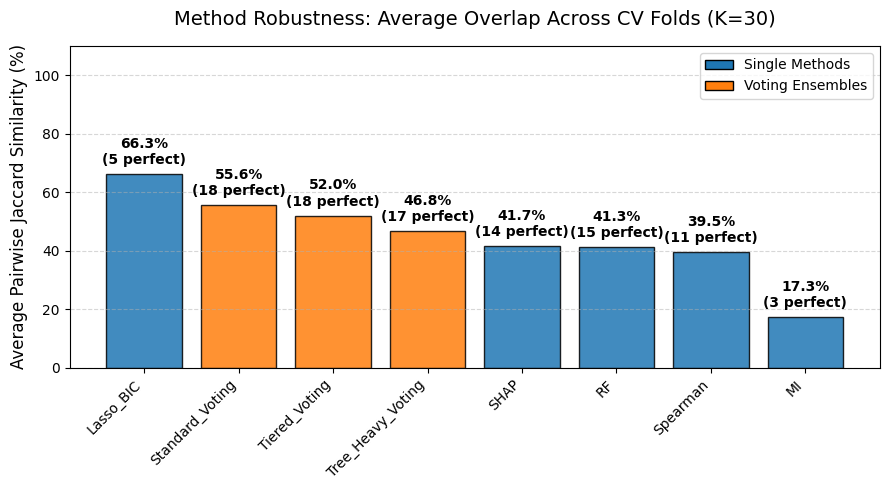

In [ ]:
def calculate_pairwise_jaccard(fold_features_list, k):
    """Calculates the average Jaccard similarity across all unique pairs of folds."""
    jaccard_scores = []
    
    for set1, set2 in combinations([set(f[:k]) for f in fold_features_list], 2):
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_scores.append(intersection / union if union > 0 else 0)
        
    return np.mean(jaccard_scores) * 100

def plot_stability_analysis(stability_tracker, k=30):
    stability_results = []
    
    for method_name, fold_lists in stability_tracker.items():
        # Metric 1: Average Pairwise Jaccard
        avg_jaccard = calculate_pairwise_jaccard(fold_lists, k)
        
        # Metric 2: Perfect Consensus (Features in ALL 5 folds)
        all_folds_sets = [set(f[:k]) for f in fold_lists]
        perfect_features = len(set.intersection(*all_folds_sets))
        
        stability_results.append({
            'Method': method_name,
            'Average Jaccard Overlap (%)': avg_jaccard,
            'Perfect 5/5 Features': perfect_features
        })
        
    df_stability = pd.DataFrame(stability_results).sort_values(by='Average Jaccard Overlap (%)', ascending=False)
    
    print("=== FEATURE SELECTION STABILITY ACROSS FOLDS ===")
    print(df_stability.to_string(index=False))
    
    # ---------------- Plotting ----------------
    plt.figure(figsize=(9, 5))
    
    colors = ['#ff7f0e' if 'Voting' in m else '#1f77b4' for m in df_stability['Method']]
    
    bars = plt.bar(df_stability['Method'], df_stability['Average Jaccard Overlap (%)'], 
                   color=colors, edgecolor='black', alpha=0.85)
    
    plt.title(f'Method Robustness: Average Overlap Across CV Folds (K={k})', fontsize=14, pad=15)
    plt.ylabel('Average Pairwise Jaccard Similarity (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 110)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar, perfect in zip(bars, df_stability['Perfect 5/5 Features']):
        height = bar.get_height()
        plt.annotate(f"{height:.1f}%\n({perfect} perfect)", 
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5), textcoords="offset points", 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1f77b4', edgecolor='black', label='Single Methods'),
                       Patch(facecolor='#ff7f0e', edgecolor='black', label='Voting Ensembles')]
    plt.legend(handles=legend_elements, loc='upper right')
        
    plt.tight_layout()
    plt.show()

plot_stability_analysis(stability_tracker, k=top_k_target)

## 7. Global Method Agreement (Pairwise Jaccard Similarity)

Now that we have our definitive global rankings for all 8 methods (5 Base + 3 Voting Ensembles), we want to understand how much these methodologies overlap with one another. 

We calculate the **Jaccard Similarity** ($J = \frac{|A \cap B|}{|A \cup B|}$) between the Top 30 features of every possible pair of methods. 
* **100%** means both methods selected the exact same 30 variables.
* **0%** means the methods have completely disjoint sets of variables.

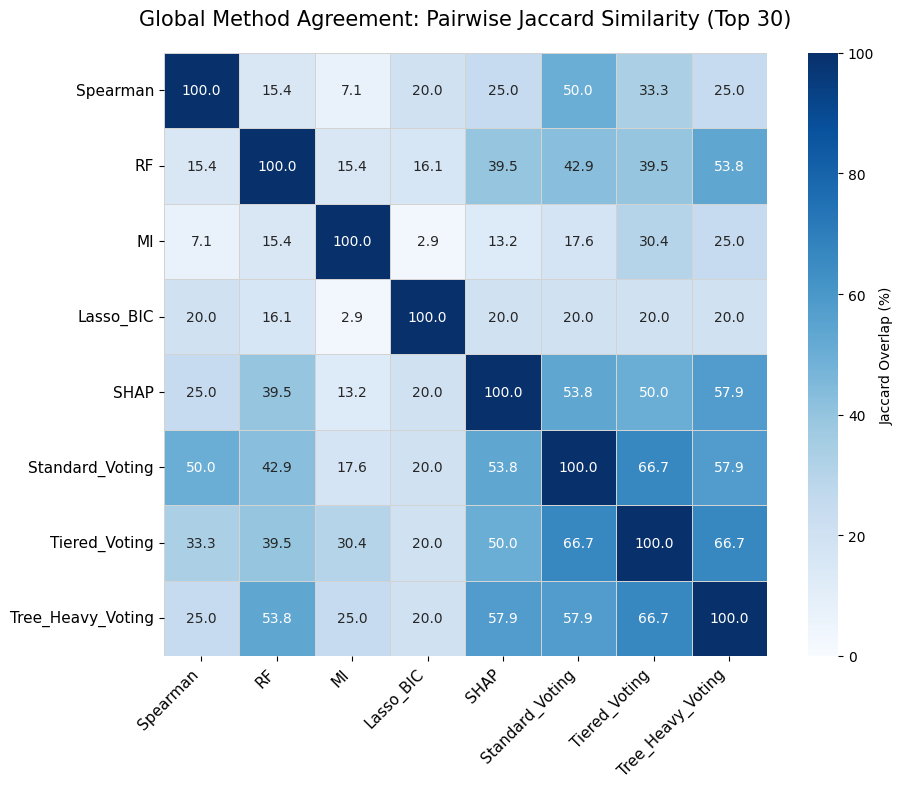

In [ ]:
import seaborn as sns

def calculate_global_method_jaccard(global_ranks_dict, top_k=30):
    """
    Calculates the Jaccard similarity percentage between all pairs of methods 
    using their final global rankings.
    """
    methods = list(global_ranks_dict.keys())
    n = len(methods)
    jaccard_matrix = pd.DataFrame(np.zeros((n, n)), index=methods, columns=methods)
    
    for i in range(n):
        for j in range(n):
            set1 = set(global_ranks_dict[methods[i]][:top_k])
            set2 = set(global_ranks_dict[methods[j]][:top_k])
            
            intersection = len(set1.intersection(set2))
            union = len(set1.union(set2))
            
            jaccard_matrix.iloc[i, j] = (intersection / union) * 100 if union > 0 else 0
            
    return jaccard_matrix

j_matrix_global = calculate_global_method_jaccard(final_all_ranks, top_k=top_k_target)

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))

sns.heatmap(j_matrix_global, annot=True, cmap='Blues', fmt=".1f", vmin=0, vmax=100, 
            cbar_kws={'label': 'Jaccard Overlap (%)'}, square=True, 
            linewidths=0.5, linecolor='lightgrey')

plt.title(f'Global Method Agreement: Pairwise Jaccard Similarity (Top {top_k_target})', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

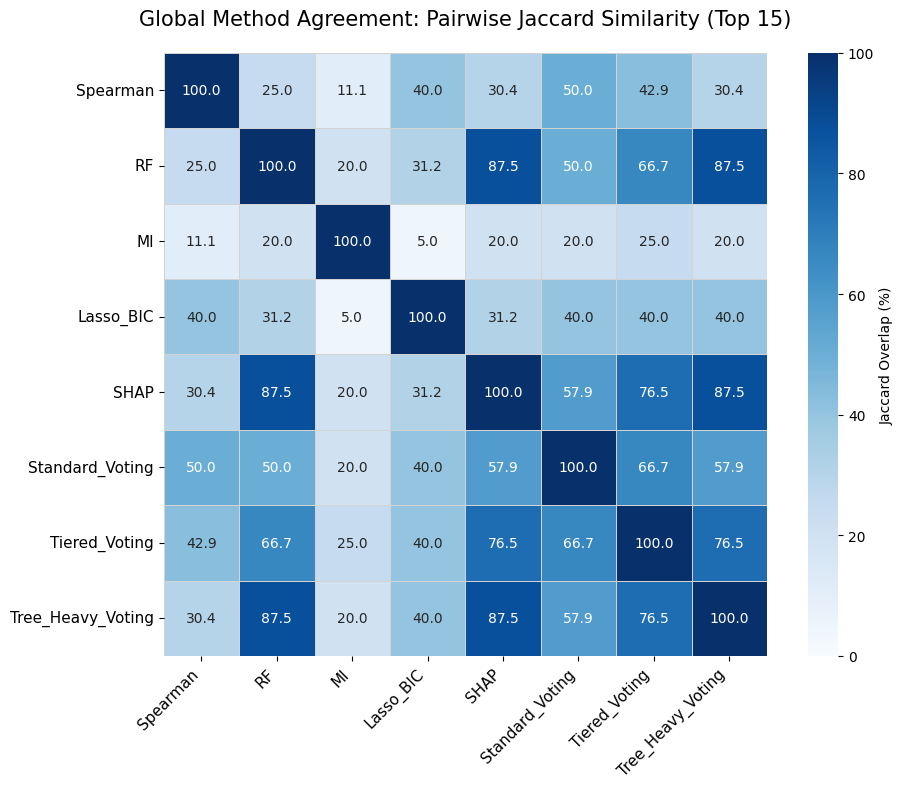

In [13]:
j_matrix_global = calculate_global_method_jaccard(final_all_ranks, top_k=15)

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))

sns.heatmap(j_matrix_global, annot=True, cmap='Blues', fmt=".1f", vmin=0, vmax=100, 
            cbar_kws={'label': 'Jaccard Overlap (%)'}, square=True, 
            linewidths=0.5, linecolor='lightgrey')

plt.title(f'Global Method Agreement: Pairwise Jaccard Similarity (Top 15)', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

## 8. Ensemble Visualization & Report Graphics

To effectively communicate the value of our ensemble approach in the final report, we generate two key visualizations:
1. **The Rank Flow (Bump Chart):** Illustrates how the Top 15 features shifted in ranking across the base methodologies. Flat lines indicate universal mathematical consensus; jagged lines indicate algorithm-specific biases.
2. **The Stacked Contribution Chart:** Deconstructs the final score of the winning features, proving that our final selection draws robust power from both linear and non-linear base algorithms.

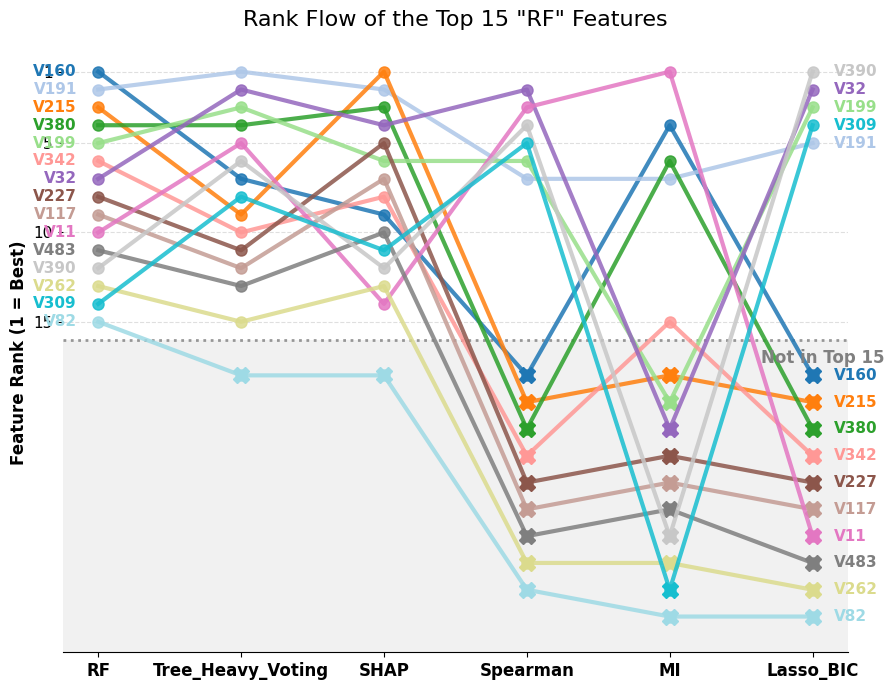

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bump_chart(all_ranks_dict, winning_method, base_methods, top_n=15, max_rank=30):
    """
    Plots a Rank Flow chart. Features not in the Top 30 are logged as -1, 
    but are vertically staggered within a shaded "Dropout Zone" so they never overlap.
    """

    top_features = all_ranks_dict[winning_method][:top_n]
    
    rank_data_actual = {feat: [] for feat in top_features}
    rank_data_plotted = {feat: [] for feat in top_features}
    
    missing_counters = {method: 0 for method in base_methods}
    
    missing_start_y = max_rank + 3 
    spread_step = 1.5
    
    for feat in top_features:
        for method in base_methods:
            method_list = all_ranks_dict[method][:max_rank]
            if feat in method_list:
                r = method_list.index(feat) + 1
                rank_data_actual[feat].append(r)
                rank_data_plotted[feat].append(r)
            else:
                rank_data_actual[feat].append(-1)
                
                y_offset = missing_counters[method] * spread_step
                rank_data_plotted[feat].append(missing_start_y + y_offset)
                missing_counters[method] += 1
                
    max_y_plotted = max([max(ranks) for ranks in rank_data_plotted.values()])
    
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab20(np.linspace(0, 1, len(top_features)))
    x_positions = range(len(base_methods))
    
    ax.axhspan(max_rank + 1, max_y_plotted + 2, facecolor='lightgrey', alpha=0.3)
    ax.axhline(max_rank + 1, color='grey', linestyle=':', linewidth=2, alpha=0.8)
    ax.text(len(base_methods) - 0.5, max_rank + 1.5, f'Not in Top {max_rank}', 
            color='grey', fontsize=12, ha='right', va='top', fontweight='bold')
    
    for (feat, plotted_ranks), actual_ranks, color in zip(rank_data_plotted.items(), rank_data_actual.values(), colors):
        ax.plot(x_positions, plotted_ranks, marker='o', markersize=8, linewidth=3, 
                label=feat, color=color, alpha=0.85)
        
        for i, r in enumerate(actual_ranks):
            if r == -1:
                ax.plot(x_positions[i], plotted_ranks[i], marker='X', markersize=12, color=color)
     
        ax.text(x_positions[0] - 0.15, plotted_ranks[0], feat, ha='right', va='center', 
                fontsize=11, fontweight='bold', color=color)
        ax.text(x_positions[-1] + 0.15, plotted_ranks[-1], feat, ha='left', va='center', 
                fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(base_methods, fontsize=12, fontweight='bold')
    
    ax.set_ylim(max_y_plotted + 2, 0)
    
    y_ticks = [1, 5, 10, 15]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(y) for y in y_ticks], fontsize=11)
    
    ax.set_ylabel('Feature Rank (1 = Best)', fontsize=12, fontweight='bold')
    ax.set_title(f'Rank Flow of the Top {top_n} "{winning_method}" Features', fontsize=16, pad=20)
    
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

base_methods_to_track = ['RF', 'Tree_Heavy_Voting', 'SHAP', 'Spearman', 'MI', 'Lasso_BIC']

plot_bump_chart(final_all_ranks, robust_global_best['Method'], base_methods_to_track, top_n=15, max_rank=15)

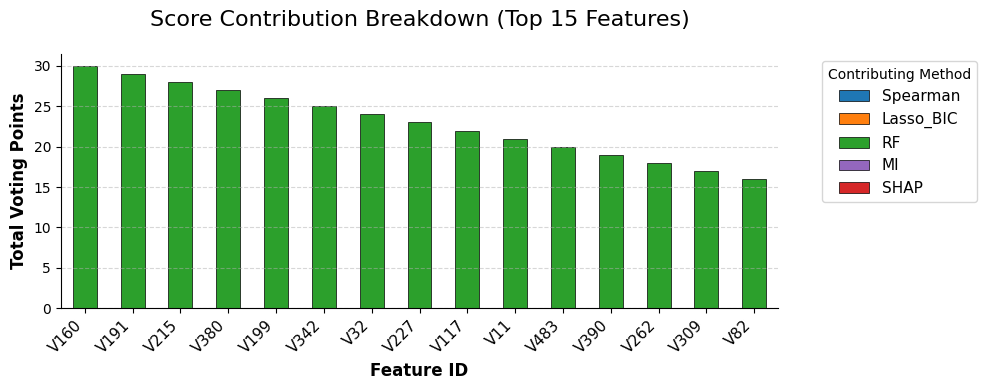

In [ ]:
def plot_stacked_contribution(base_ranks, weights, winning_features, top_k=30, top_n_to_plot=15):
    """
    Deconstructs the total score of the winning features and plots a stacked bar chart 
    showing how much each base method contributed to their success.
    """

    features_to_plot = winning_features[:top_n_to_plot]
    breakdown_records = []
    
    for method, feats in base_ranks.items():
        w = weights.get(method, 1.0)
        for rank, f in enumerate(feats):
            if f in features_to_plot:
                points = (top_k - rank) * w
                breakdown_records.append({'Feature': f, 'Method': method, 'Points': points})
                
    df_breakdown = pd.DataFrame(breakdown_records)
    
    pivot_df = df_breakdown.pivot(index='Feature', columns='Method', values='Points').fillna(0)
    
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns=['Total'])
  
    fig, ax = plt.subplots(figsize=(10, 4))
    
    method_colors = {
        'Spearman': '#1f77b4',
        'Lasso_BIC': '#ff7f0e',
        'RF': '#2ca02c',
        'MI': '#9467bd',
        'SHAP': '#d62728'
    }
    
    cols = [m for m in ['Spearman', 'Lasso_BIC', 'RF', 'MI', 'SHAP'] if m in pivot_df.columns]
    pivot_df = pivot_df[cols]
    
    pivot_df.plot(kind='bar', stacked=True, color=[method_colors[c] for c in pivot_df.columns], 
                  ax=ax, edgecolor='black', linewidth=0.5)
    
    ax.set_title(f'Score Contribution Breakdown (Top {top_n_to_plot} Features)', fontsize=16, pad=20)
    ax.set_xlabel('Feature ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('Total Voting Points', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.legend(title='Contributing Method', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Plotting the winning single method's ranking
weights_used = {'Spearman': 0, 'RF': 1, 'MI': 0, 'Lasso_BIC': 0, 'SHAP': 0} 

plot_stacked_contribution(
    final_base_ranks, 
    weights_used, 
    final_all_ranks[robust_global_best['Method']],
    top_k=top_k_target, 
    top_n_to_plot=15
)

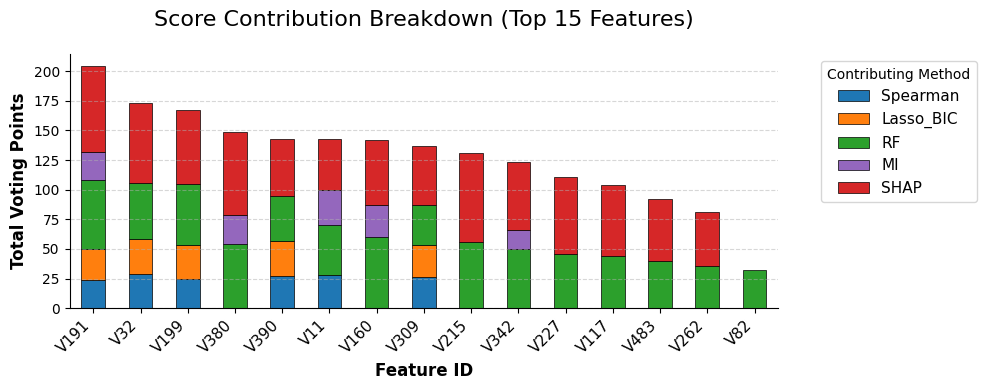

In [ ]:
# Plotting the winning enseble's ranking
weights_used = {'Spearman': 1, 'RF': 2, 'MI': 1, 'Lasso_BIC': 1, 'SHAP': 2.5} 

# Execute the plot
plot_stacked_contribution(
    final_base_ranks, 
    weights_used, 
    final_all_ranks[robust_global_best['Method']], # The list of features to plot
    top_k=top_k_target, 
    top_n_to_plot=15
)